# Dataset: **Diabetes** (scikit-learn)
442 real patients, 10 characteristics.

> Rule: Everything built from scratch with NumPy; scikit-learn added last.

## Part 0 (Setup & Dataset)

### `load_diabetes(scaled=False)`
Raw values. Requires `numpy`, `pandas`, `matplotlib`, `plotly`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Reproducibility: same random numbers for everyone
rng = np.random.default_rng(42)

# NumPy and pandas should print width without splitting rows or using scientific notation.
np.set_printoptions(linewidth=140, suppress=True, precision=3)
pd.set_option("display.width", 140)

data = load_diabetes(scaled=False)
X_full = data.data                  # (442, 10) characteristics
y = data.target                     # (442,) disease progression

print(f"{X_full.shape[0]} | Characteristics: {X_full.shape[1]}")

# We see it as a table: much more readable than a raw array
df = pd.DataFrame(X_full, columns=data.feature_names)
df["progression"] = y
df.head()

442 | Characteristics: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


## Beware of the very different scales of the columns (`s1` up to 301, `s4` from 2 to 9).

In [2]:
df.describe().round(1)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
count,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0,442.0
mean,48.5,1.5,26.4,94.6,189.1,115.4,49.8,4.1,4.6,91.3,152.1
std,13.1,0.5,4.4,13.8,34.6,30.4,12.9,1.3,0.5,11.5,77.1
min,19.0,1.0,18.0,62.0,97.0,41.6,22.0,2.0,3.3,58.0,25.0
25%,38.2,1.0,23.2,84.0,164.2,96.0,40.2,3.0,4.3,83.2,87.0
50%,50.0,1.0,25.7,93.0,186.0,113.0,48.0,4.0,4.6,91.0,140.5
75%,59.0,2.0,29.3,105.0,209.8,134.5,57.8,5.0,5.0,98.0,211.5
max,79.0,2.0,42.2,133.0,301.0,242.4,99.0,9.1,6.1,124.0,346.0


One single feature required for graphing: **BMI**

$$\hat{y} = \theta_0 + \theta_1 * x_{bmi}$$

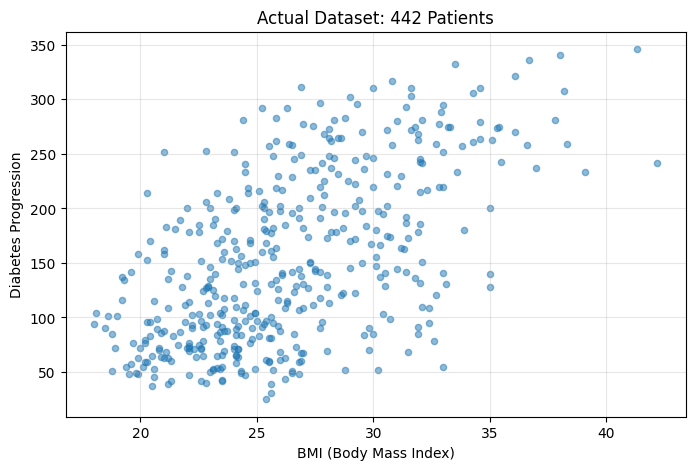

BMI → min: 18.0 | max: 42.2 | mean: 26.4
y   → min: 25 | max: 346 | mean: 152.1


In [3]:
# We select the BMI feature (column 2)

x_bmi = X_full[:, 2]

plt.figure(figsize=(8, 5))
plt.scatter(x_bmi, y, alpha=0.5, s=20)
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Diabetes Progression")
plt.title("Actual Dataset: 442 Patients")
plt.grid(alpha=0.3)
plt.show()

print(f"BMI → min: {x_bmi.min():.1f} | max: {x_bmi.max():.1f} | mean: {x_bmi.mean():.1f}")
print(f"y   → min: {y.min():.0f} | max: {y.max():.0f} | mean: {y.mean():.1f}")